In [12]:
import sys
from pathlib import Path
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
import scienceplots

plt.style.use(['science'])

In [22]:
def add_arrow(ax, start, end, color='k', lw=2.5, mutation_scale=10):
    arrow = FancyArrowPatch(start, end, color=color, lw=lw, arrowstyle='-|>',
                            joinstyle='miter', mutation_scale=mutation_scale)
    ax.add_patch(arrow)

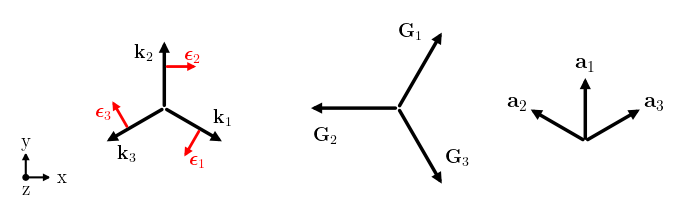

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(7, 3), width_ratios = [4, 3, 3])
for ax in axes:
    ax.set_aspect('equal')
    ax.axis('off')

# k vectors and polarization vectors
ax = axes[0]
ax.set_xlim(-2.3, 1.5)
ax.set_ylim(-1.5, 1.5)

k_vecs = [E9c.k1k, E9c.k2k, E9c.k3k]
e_vecs = [E9c.e_pol1, E9c.e_pol2, E9c.e_pol3]
k_labels = [r'$\mathbf{k}_1$', r'$\mathbf{k}_2$', r'$\mathbf{k}_3$']
e_labels = [r'$\boldsymbol{\epsilon}_1$', r'$\boldsymbol{\epsilon}_2$', r'$\boldsymbol{\epsilon}_3$']

for i in range(3):
    k = k_vecs[i]
    e = e_vecs[i]
    
    # Draw k vector pointing outwards
    add_arrow(ax, (0, 0), k, color='k')
    
    # Add k label (shifted slightly off the midpoint)
    label_offset = np.array([-k[1], k[0]]) * 0.3 # Orthogonal shift
    ax.text(k[0]*0.8 + label_offset[0], k[1]*0.8 + label_offset[1], 
            k_labels[i], fontsize=14, ha='center', va='center')
    
    # Epsilon vector (placed 20% away from the k arrow head)
    e_scale = 0.5 # Visual length of the epsilon arrow
    e_start = k * 0.6
    e_end = e_start + (e * e_scale)
    
    add_arrow(ax, e_start, e_end, color='red', lw=2, mutation_scale=8)
    
    # Add epsilon label
    ax.text(e_end[0] * 0.8 + k[0]*0.3, e_end[1] * 0.8 + k[1]*0.3, e_labels[i], 
            color='red', fontsize=14, ha='center', va='center')

# Add XYZ coordinate triad
triad_origin = np.array([-2, -1.0])
add_arrow(ax, triad_origin, triad_origin + np.array([0.4, 0]), lw=1.5, mutation_scale=8)
add_arrow(ax, triad_origin, triad_origin + np.array([0, 0.4]), lw=1.5, mutation_scale=8)
ax.add_patch(Circle(triad_origin, 0.04, color='k')) # z-axis coming out of page
ax.text(triad_origin[0] + 0.45, triad_origin[1], 'x', fontsize=14, va='center')
ax.text(triad_origin[0], triad_origin[1] + 0.45, 'y', fontsize=14, ha='center')
ax.text(triad_origin[0], triad_origin[1] - 0.25, 'z', fontsize=14, ha='center')

# G vectors
ax = axes[1]
ax.set_xlim(-2.3, 1.5)
ax.set_ylim(-2., 2.)

g_vecs = [E9c.g1g, E9c.g2g, E9c.g3g]
g_labels = [r'$\mathbf{G}_1$', r'$\mathbf{G}_2$', r'$\mathbf{G}_3$']

for i in range(3):
    g = g_vecs[i]
    label_offset = np.array([-g[1], g[0]]) * 0.3
    add_arrow(ax, (0, 0), g, color='k', lw=2.5)
    
    # Place label at the tip of the arrow
    label_pos = g * 1.15
    ax.text(label_pos[0] * 0.7 + label_offset[0], label_pos[1] * 0.7 + label_offset[1],
            g_labels[i], fontsize=14, ha='center', va='center')

# Lattice vectors
ax = axes[2]
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-0.5, 1.5)

a_vecs = [E9c.a1, E9c.a2, E9c.a3]
a_labels = [r'$\mathbf{a}_1$', r'$\mathbf{a}_2$', r'$\mathbf{a}_3$']

for i in range(3):
    a = a_vecs[i] / E9c.a_sw_tri
    add_arrow(ax, (0, 0), a, color='k', lw=2.5)
    
    # Place label at the tip of the arrow
    label_pos = a * 1.2
    ax.text(label_pos[0], label_pos[1], a_labels[i], fontsize=16, ha='center', va='center')

fig.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\theory")
file_full_path = Path(thesis_fig_path, "vec_conventions.pdf")
fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')